In [21]:
from glob import glob
import librosa    
from pathlib import Path

In [55]:
sounds = glob("./data/*/*.wav")

def extract_features(y, sr):
    features = []  

    y_trimmed, _ = librosa.effects.trim(y=y, top_db=40)

    # RMS - root mean squared : energy / loudness over time
    rms = librosa.feature.rms(y=y)
    rms_mean = rms.mean()
    features.append(rms_mean)

    # ZCR - zero crossing rate : noise / frequency 
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = zcr.mean()
    features.append(zcr_mean)

    # Spectral Centroid - "center of mass" : energy location on frequency spectrum : where is the noise coming from? 
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    centroid_mean = centroid.mean()
    features.append(centroid_mean)

    # Spectral Rolloff - "Below what frequency does most (default: 85%) of the energy lie?”
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = rolloff.mean()
    features.append(rolloff_mean)

    # bandwidth - "How spread out are the frequencies?"
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    bandwidth_mean = bandwidth.mean()
    features.append(bandwidth_mean)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)
    mfcc_means = mfcc.mean(axis=1)
    features.extend(mfcc_means)
    return features

X = []
y = []
for sound in sounds:
    waveform, sr = librosa.load(sound)
    features = extract_features(waveform, sr)
    label = Path(sound).parent.name
    # print(label)
    X.append(features)
    y.append(label)
print('done')

done


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

labels = sorted(set(y))
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=.8, stratify=y)

# scale
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('done')

done


Classification Report
               precision    recall  f1-score   support

        kick       1.00      1.00      1.00         8
   overheads       1.00      0.88      0.93         8
       snare       0.89      1.00      0.94         8
        toms       1.00      1.00      1.00         8

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32



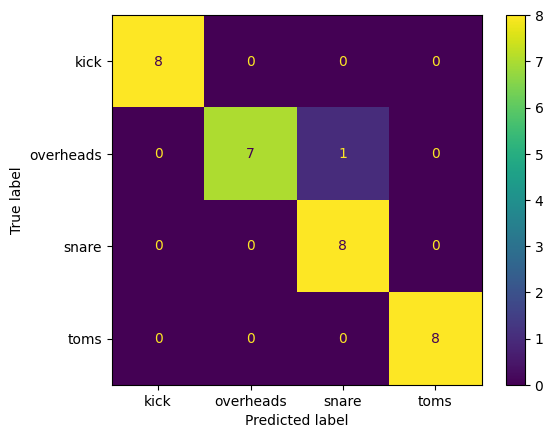

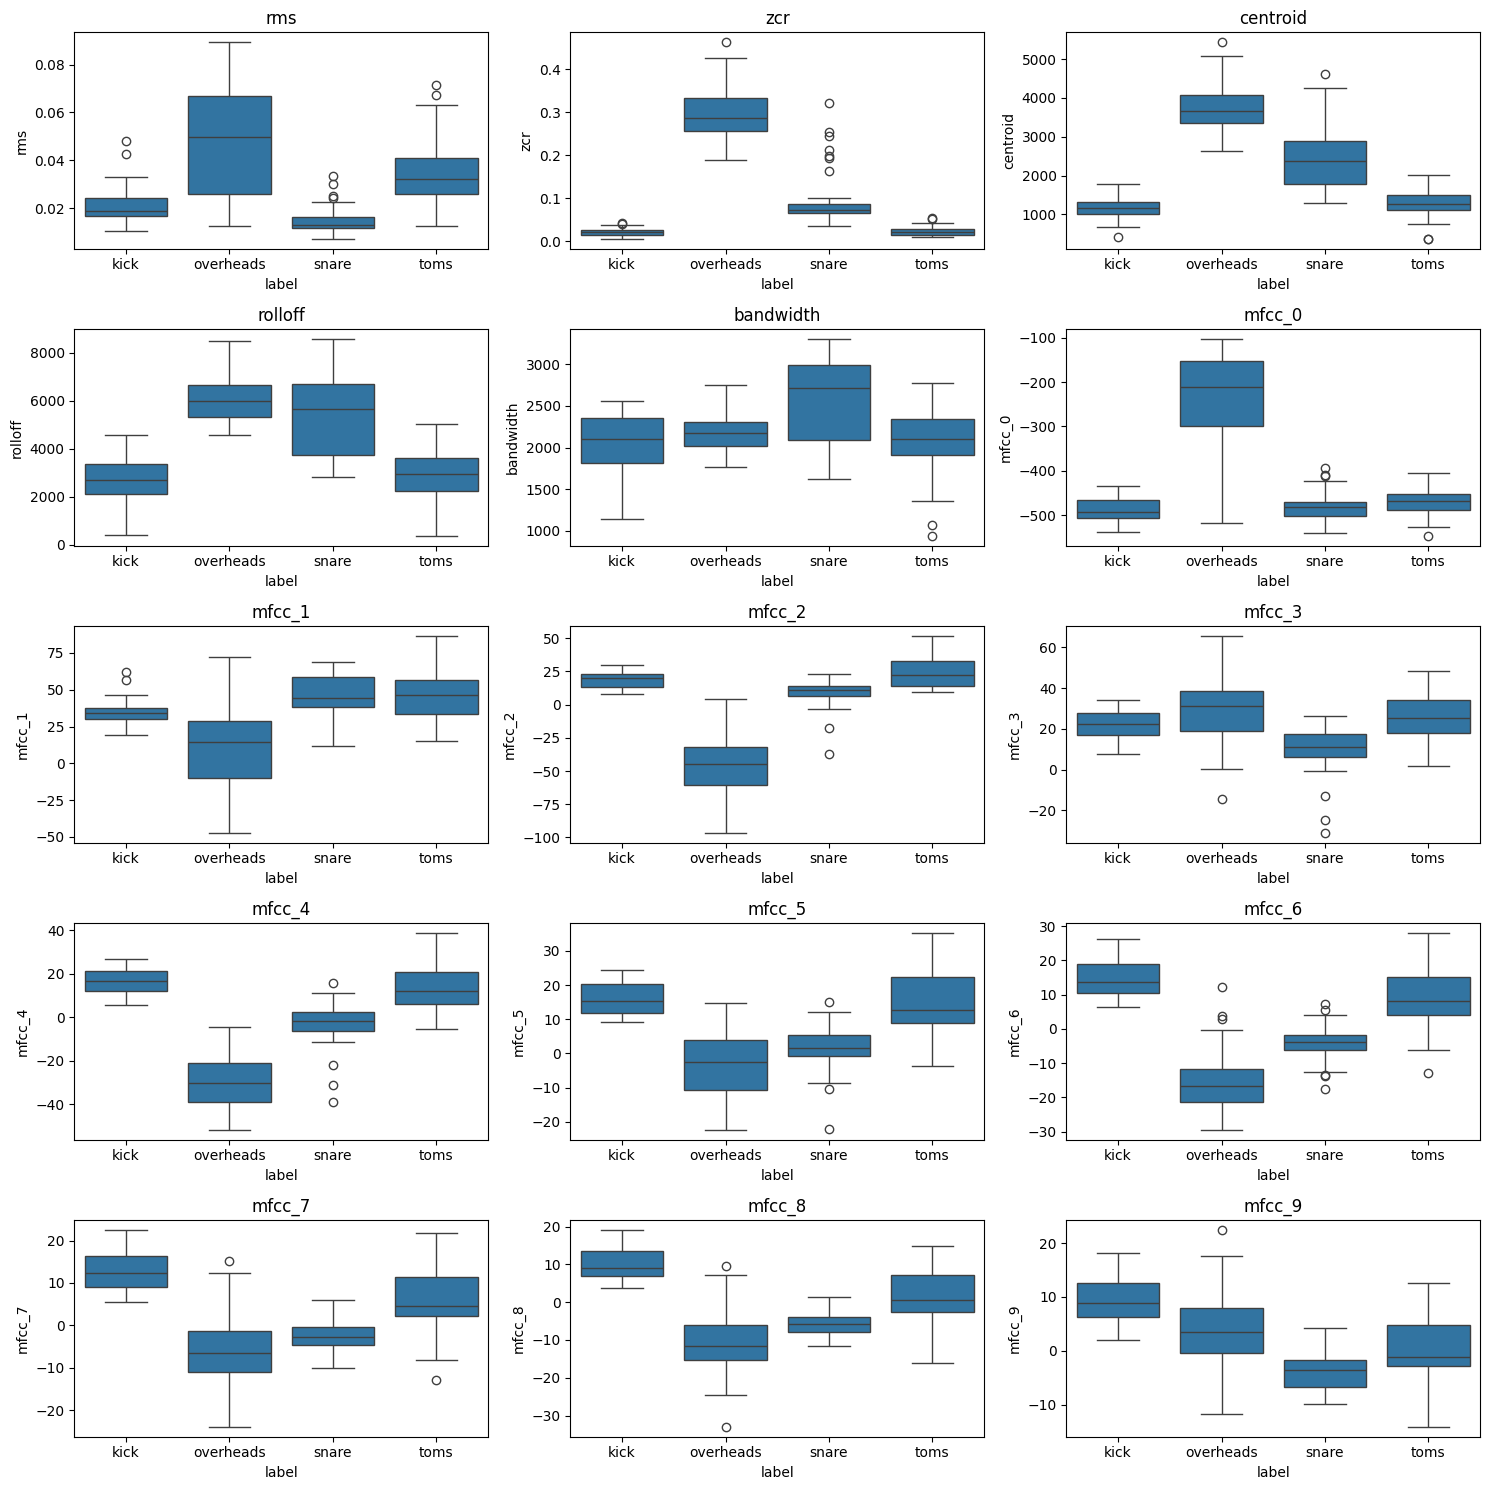

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labels)

cr = classification_report(y_test, pred)
print("Classification Report\n", cr)

# make plots
feature_names = [
    "rms",
    "zcr",
    "centroid",
    "rolloff",
    "bandwidth",
] + [f"mfcc_{i}" for i in range(10)]

df = pd.DataFrame(X, columns=feature_names)
df["label"] = y

fig, axes = plt.subplots(5, 3, figsize=(15, 15))

for i, feature in enumerate(feature_names):
    row = i // 3
    col = i % 3
    sns.boxplot(x="label", y=feature, data=df, ax=axes[row][col])
    axes[row][col].set_title(feature)

plt.tight_layout()
plt.show()